In [1]:
import pandas as pd

df= pd.read_csv('CarPrice_Assignment.csv')
df.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [3]:
X =df[['enginesize']]
y= df['price']

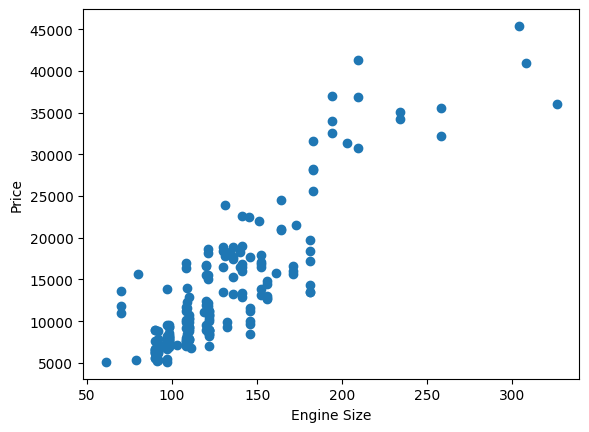

In [8]:
#visualize the rln bte enginesize and price
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()


In [29]:
#Buil a predictive model to estimate car price based on engine size using linear regression and polynomial regression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
print(f'Linear Regression MSE: {mse_linear}, R2: {r2_linear}')


from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=3)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f'Polynomial Regression MSE: {mse_poly}, R2: {r2_poly}')


Linear Regression MSE: 15465458.96590847, R2: 0.8040958796678975
Polynomial Regression MSE: 11621389.455322495, R2: 0.8527894915178168


In [11]:
#increase the flexibility of the polynomial regression model by using a higher degree polynomial (e.g., degree=3 or degree=4) and evaluate its performance compared to the linear regression model.

poly_features_high = PolynomialFeatures(degree=4)
X_train_poly_high = poly_features_high.fit_transform(X_train)
X_test_poly_high = poly_features_high.transform(X_test)
poly_model_high = LinearRegression()
poly_model_high.fit(X_train_poly_high, y_train)
y_pred_poly_high = poly_model_high.predict(X_test_poly_high)
mse_poly_high = mean_squared_error(y_test, y_pred_poly_high)
r2_poly_high = r2_score(y_test, y_pred_poly_high)
print(f'High-Degree Polynomial Regression MSE: {mse_poly_high}, R2: {r2_poly_high}')


High-Degree Polynomial Regression MSE: 11649790.194971029, R2: 0.8524297335610764


In [25]:
#predict car price for a specific engine size using both models
engine_size = [[200]]   
price_linear = linear_model.predict(engine_size)
price_poly = poly_model.predict(poly_features.transform(engine_size))
print(f'Predicted price using Linear Regression: {price_linear[0]}')
print(f'Predicted price using Polynomial Regression: {price_poly[0]}')


Predicted price using Linear Regression: 25427.147445039864
Predicted price using Polynomial Regression: 27760.608345384946


C:\Users\Hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [23]:
#accuracies of all three models
print(f'Linear Regression R2: {r2_linear}')
print(f'Polynomial Regression (degree=3) R2: {r2_poly}')
print(f'High-Degree Polynomial Regression (degree=4) R2: {r2_poly_high}')


Linear Regression R2: 0.8040958796678975
Polynomial Regression (degree=3) R2: 0.8527894915178168
High-Degree Polynomial Regression (degree=4) R2: 0.8524297335610764


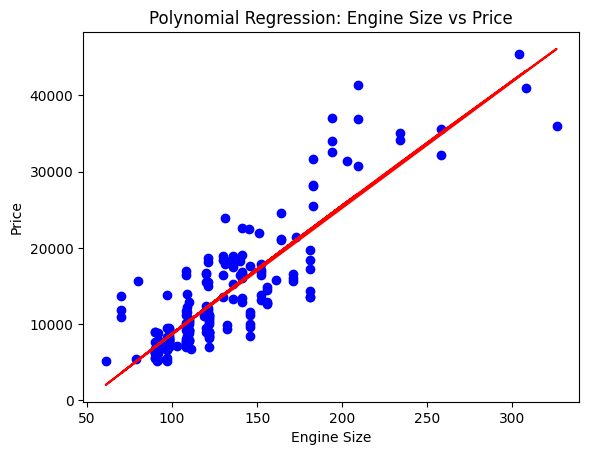

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

model = PolynomialFeatures(degree=2)
X_poly = model.fit_transform(X)
from sklearn.linear_model import LinearRegression
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred = poly_reg.predict(X_poly)
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Polynomial Regression: Engine Size vs Price')
plt.show()



C:\Users\Hello\AppData\Local\Temp\ipykernel_27396\1206752138.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
C:\Users\Hello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


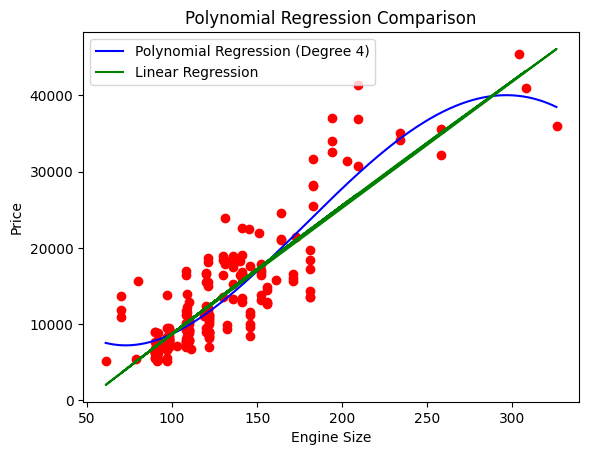

In [35]:
# Visualising the Polynomial Regression results (for higher resolution and smoother curve) and linear regression on same plot

# import numpy as np
# X_grid = np.arange(min(X.values), max(X.values), 0.1)
# X_grid = X_grid.reshape((len(X_grid), 1))
# plt.scatter(X, y, color='red')
# plt.plot(X_grid, poly_model_high.predict(poly_features_high.transform(X_grid)), color='blue')
# plt.plot(X, y_pred, color='green')
# plt.title('Polynomial Regression (Degree 4)')
# plt.xlabel('Engine Size')
# plt.ylabel('Price')
# plt.show()

import numpy as np
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color='red')
plt.plot(X_grid, poly_model_high.predict(poly_features_high.transform(X_grid)), color='blue', label='Polynomial Regression (Degree 4)')
plt.plot(X, y_pred, color='green', label='Linear Regression')
plt.title('Polynomial Regression Comparison')   
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.legend()
plt.show()

